# Michael Vazquez<br>Econ 570, Assignment 4<br>PCA and Factor Models Applied to S&P 500 Returns<br>Link to code: https://github.com/Vazquez-Michael-V/570_homework/blob/main/assignment_4/econ_570_assignment_4.ipynb

# Imports and Settings.

In [95]:
import pandas as pd
import numpy as np
import scipy.stats

import statsmodels.formula.api as smf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

from IPython.display import display, Math, Image


# Module that I made for summary statistics of interest to Econ 570.
# More functions may be added later in the course.
from econ_570_mod.summary_statistics import summary_statistics


# The 'cm' font nicely displays Greek characters.
plt.rcParams.update({
    'figure.dpi':        120,
    'font.size':         11,
    'mathtext.fontset':  'cm',
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

%matplotlib inline


# Load and clean the dataset.

In [96]:
df = pd.read_csv(
    'A4_dataset-2.csv'
).rename(
    columns={'sp500_ret': 'y'}
).astype(
    {'date': 'datetime64[ns]'}
).sort_values(
    'date'
).reset_index(drop=True)

df = df.set_index('date')

for col in df.columns:
    assert not df[col].hasnans, f"Column '{col}' has at least one NaN."


# Notebook variables.
#### NOTE: Lecture 22, slide 18 "Empirical Illustration: Forecasting the Term Structure", introduces the terms level, slope, and curvature for f1, f2, and f3. Thus the FACTOR_LABELS variable has both the f1, f2, f3, as required by the assignment, and the name corresponding to each f.

In [97]:
# IR to abbreviate 'Interest Rate' here.
# In the assignment, we are told that these are all interest rate columns.
IR_COLS = [col for col in df.columns if 'DGS' in col]

# The timeframe corresponding to each column name.
IR_LABELS = [
    f"{col[3:].replace('MO', 'M')}" if 'MO' in col else f"{col.replace('DGS', '')}Y"
    for col in df.columns if col != 'y'
]

# Place the column names and their corresponding timeframe into a dictionary.
IR_LABEL_MAP = {k: v for k, v in zip(IR_COLS, IR_LABELS)}

# Per class discussions, 3 factors is often sufficient.
N_FACTORS = 3

# Set up the colors to be consistent throughout the notebook.
FACTOR_COLS = ['f1', 'f2', 'f3']
# Lecture 22, slide "Empirical Illustration: Forecasting the Term Structure",
# introduces the terms level, slope, and curvature for f1, f2, and f3.
FACTOR_LABELS = ['f1 (Level)', 'f2 (Slope)', 'f3 (Curvature)']
FACTOR_COLORS = ['#1f77b4', '#d62728', '#2ca02c']

# Economic events that we've discussed in the midterm and previous assignments.
# Looked up the dates.
EVENTS = [
    ('2008-09-15', 'Financial Crisis'),
    ('2020-03-16', 'COVID'),
    ('2022-03-17', 'Fed Rate Hikes'),
]

# HAC lag, approximately 1 trading week since we are given daily data,
# and the assignment does not specify the lag.
HAC_MAXLAGS = 5



## Summary statistics and sample rows.

In [98]:

print('S&P 500 daily return summary statistics:')
display(summary_statistics(df, 'y', 'date')['df_summary_stats'])

# TODO: Should add min and max to summary_statistics().
print('S&P 500 daily return summary min and max:')
display(df['y'].describe().loc[['min', 'max']])

print('\nInterest rate summary statistics for all timeframes:')
display(
    df.loc[:, IR_COLS]
    .describe()
    .T
    .rename(index=IR_LABEL_MAP)
    .round(4)
)

print("Sample rows:")
display(df.sample(n=10))

S&P 500 daily return summary statistics:


,statistic,value
0,mean,0.0003
1,median,0.0007
2,var,0.0001
3,std_dev,0.0120
4,skewness,-0.5133
5,kurtosis,10.9211


S&P 500 daily return summary min and max:


min   -0.127652
max    0.102457
Name: y, dtype: float64


Interest rate summary statistics for all timeframes:


,count,mean,std,min,25%,50%,75%,max
1M,6156.0,1.6825,1.8353,0.00,0.08,0.990,2.8000,6.02
3M,6156.0,1.7411,1.8427,0.00,0.10,1.080,3.0725,5.63
6M,6156.0,1.8314,1.8273,0.02,0.15,1.200,3.2900,5.61
1Y,6156.0,1.8991,1.7405,0.04,0.26,1.390,3.3700,5.49
2Y,6156.0,2.0609,1.5833,0.09,0.61,1.670,3.5300,5.29
3Y,6156.0,2.2349,1.4726,0.10,0.94,1.935,3.6200,5.26
5Y,6156.0,2.5979,1.3190,0.19,1.52,2.520,3.8000,5.23
7Y,6156.0,2.9039,1.2280,0.36,1.92,2.900,3.9700,5.29
10Y,6156.0,3.1764,1.1703,0.52,2.20,3.230,4.2000,5.44
20Y,6156.0,3.7011,1.1943,0.87,2.67,3.910,4.7400,6.05


Sample rows:


,DGS1MO,DGS3MO,DGS6MO,DGS1,DGS2,DGS3,DGS5,DGS7,DGS10,DGS20,DGS30,y
date,,,,,,,,,,,,
2002-07-30,1.73,1.72,1.75,1.96,2.44,2.88,3.71,4.24,4.65,5.54,5.59,0.004240
2002-06-13,1.71,1.72,1.82,2.20,3.00,3.50,4.20,4.61,4.94,5.65,5.65,-0.010543
2007-06-05,4.75,4.83,4.99,4.99,4.99,4.97,4.96,4.96,4.98,5.16,5.07,-0.005361
2024-06-14,5.47,5.51,5.36,5.07,4.67,4.41,4.22,4.20,4.20,4.46,4.34,-0.000394
2024-12-12,4.43,4.35,4.31,4.22,4.18,4.14,4.18,4.25,4.32,4.62,4.55,-0.005429
2007-01-31,5.00,5.12,5.16,5.09,4.94,4.85,4.82,4.82,4.83,5.02,4.93,0.006571
2012-02-16,0.04,0.10,0.13,0.17,0.29,0.42,0.87,1.41,1.99,2.78,3.14,0.010965
2003-04-28,1.13,1.14,1.18,1.28,1.59,2.02,2.90,3.43,3.92,4.83,5.04,0.017678
2022-06-08,0.89,1.28,1.77,2.29,2.78,2.94,3.03,3.06,3.03,3.40,3.18,-0.010853


#### Discussion on summary statistics.

&nbsp;&nbsp;&nbsp;&nbsp;**S&P 500 returns**: The mean daily return is 0.0003 with a standard deviation of 0.0120, where the standard deviation can be interpreted as daily volatility. The median 0.0007 exceeds the mean, consistent with the negative skewness of -0.5133. This indicates that large negative returns occur more frequently and are more extreme than comparably sized positive returns. The excess kurtosis of 10.9211 indicates very heavy tails relative to a normal distribution, with a minimum return of -0.1277 and maximum of 0.1025.

&nbsp;&nbsp;&nbsp;&nbsp;**Interest rates**: The mean rate rises from 1.6825 at the 1-month maturity to 3.7953 at the 30-year maturity, which is expected yield curve behavior. Short term rates are more volatile with a standard deviation of around 1.8400 compared to long term rates having standard deviation of around 1.100. All maturity timeframes have interest rates near zero during the post 2008 and COVID rate cutting cycles.

# Using PCA to Extract Latent Factors from the Yield Curve

#### PCA setup and standardization.

&nbsp;&nbsp;&nbsp;&nbsp;Per **Lecture 18, slides 18–19**, PCA is sensitive to the units of the data. Before computing principal components, all variables must be normalized by subtracting the mean and dividing by the standard deviation of each series. In practice this is equivalent to using the **correlation matrix** of the data rather than the covariance matrix. Here `sklearn.preprocessing.StandardScaler` performs this normalization prior to decomposition.

#### PCA optimization problem (Lecture 18, slides 12–14).

Given a $(k \times 1)$ vector of variables $y_t$ with covariance matrix $\Sigma$, the $j$ th principal component is $y^p_{jt} = \alpha'_j y_t$, where the loading vector $\alpha_j$ solves:

$$\max_{\alpha_j}\; \alpha'_j \Sigma \alpha_j \qquad \text{subject to } \alpha'_j \alpha_j = 1 \text{ and } \alpha'_j \Sigma \alpha_i = 0 \text{ for all } i < j$$

The solution is the set of **eigenvectors** of $\Sigma$. If $\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_k$ are the eigenvalues and $\alpha_1, \ldots, \alpha_k$ the corresponding eigenvectors, then the variance of the $j$ th principal component is:

$$\text{var}(y^p_{jt}) = \text{var}(\alpha'_j y_t) = \lambda_j$$

and the principal components are mutually uncorrelated:

$$\text{cov}(y^p_{jt},\, y^p_{it}) = 0 \qquad \text{for all } j \neq i$$

#### Selecting $k^*$ components (Lecture 18, slide 17-18).

The fraction of total variation explained by the first $k^*$ principal components is:

$$\frac{\lambda_1 + \lambda_2 + \cdots + \lambda_{k^*}}{\lambda_1 + \lambda_2 + \cdots + \lambda_k}$$

We choose $k^* = 3$ because the first three eigenvalues together explain **99.77%** of total covariation, well above the $\eta = 0.80$ threshold recommended in the slides. Adding a fourth component contributes only 0.13%.

#### Factor model (Lecture 19, slide 3).

Given the estimated factors, the interest rates are assumed to be generated by the orthogonal factor model:

$$z_t = \mu + \Lambda F_t + \epsilon_t$$

where $z_t$ is the $(k \times 1)$ vector of interest rates, $\Lambda$ is the $(k \times k^*)$ loading matrix, $F_t = (f1_t,\, f2_t,\, f3_t)'$ is the $(k^* \times 1)$ vector of latent common factors with $k^* = 3 \ll k = 11$, and $\epsilon_t \sim (0, D)$ with $D$ diagonal.

#### Note on sign convention.
&nbsp;&nbsp;&nbsp;&nbsp;The eigenvalue equation $\Sigma\alpha_j = \lambda_j\alpha_j$ implies that PCA eigenvectors are sign-arbitrary. Thus if $\alpha_j$ is a solution, so is $-\alpha_j$. As a practical normalization, each loading vector is flipped if its mean is negative, so that the level factor $f1$ represents all rates moving upwards rather than all rates moving downwards. This convention does not affect the variance explained nor the orthogonality of the factors, which are guaranteed by the Spectral Decomposition Theorem (Lecture 18, slide 16).

In [99]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[IR_COLS])

# Full PCA across all 11 components for the scree plot.
pca_full = PCA()
pca_full.fit(X_scaled)
# evr for explained variance ratio.
evr_full = pca_full.explained_variance_ratio_

# 3-component PCA for the factors used in the regressions.
pca3 = PCA(n_components=N_FACTORS)
factors = pca3.fit_transform(X_scaled)

# Sign convention as discussed above, flip any component whose mean loading is negative.
for i in range(N_FACTORS):
    if pca3.components_[i].mean() < 0:
        pca3.components_[i] *= -1
        factors[:, i] *= -1

for i, col in enumerate(FACTOR_COLS):
    df[col] = factors[:, i]
# Compute these for discussion later in the notebook.
print(f"corr(f1, cross-maturity mean rate): {df['f1'].corr(df[IR_COLS].mean(axis=1)):.4f}")
print(f"corr(f2, 10Y-3M term spread): {df['f2'].corr(df['DGS10'] - df['DGS3MO']):.4f}")

# Place into a DataFrame to neatly display.
df_evr = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(evr_full))],
    'Explained Variance': evr_full,
    'Cumulative Variance': evr_full.cumsum(),
}).set_index('Component')

print('Explained variance ratio per principal component:')
display(
    df_evr.style
    .format('{:.6f}')
    .highlight_max(subset=['Explained Variance'], color='lightgreen')
    .set_properties(**{'background-color': 'lightblue'}, subset=pd.IndexSlice['PC3', 'Cumulative Variance'])
    .set_caption('Table 1: PCA Explained Variance')
)
print(f'\nThe 3 leading factors explain {evr_full[:3].sum()*100:.2f}% of total covariation.')
print(f"Lightgreen, largest explained variance.\nLightblue, cumulative variance at {N_FACTORS} factors.")


corr(f1, cross-maturity mean rate): 0.9983
corr(f2, 10Y-3M term spread): 0.8697
Explained variance ratio per principal component:


,Explained Variance,Cumulative Variance
Component,,
PC1,0.848391,0.848391
PC2,0.138328,0.986719
PC3,0.010953,0.997672
PC4,0.001269,0.998941
PC5,0.000469,0.999409
PC6,0.000327,0.999736
PC7,0.000132,0.999869
PC8,0.000062,0.999931
PC9,0.000035,0.999966



The 3 leading factors explain 99.77% of total covariation.
Lightgreen, largest explained variance.
Lightblue, cumulative variance at 3 factors.


## Scree plot, as shown in Lecture 18 Slide 25.

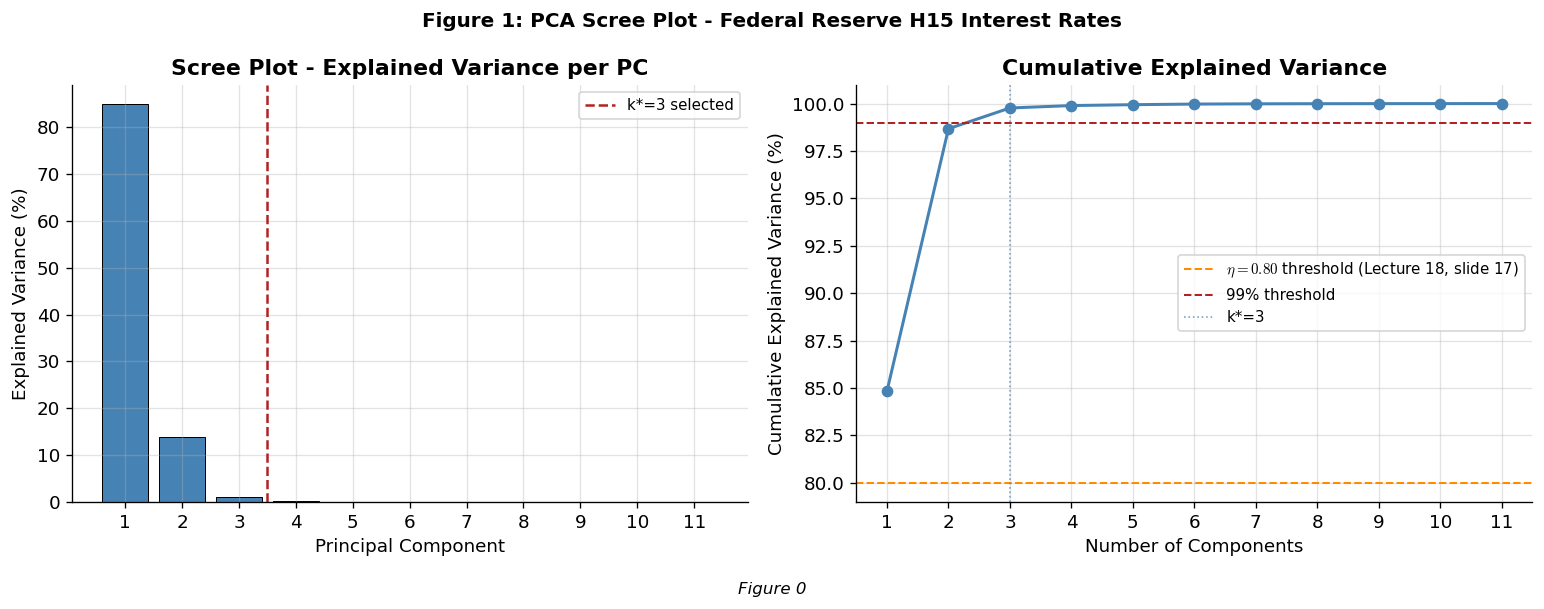

In [100]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.bar(range(1, len(evr_full) + 1), evr_full * 100,
       color='steelblue', edgecolor='black', linewidth=0.6)
ax.axvline(N_FACTORS + 0.5, color='firebrick', lw=1.5, ls='--', label=f'k*={N_FACTORS} selected')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Explained Variance (%)')
ax.set_title('Scree Plot - Explained Variance per PC', fontweight='bold')
ax.set_xticks(range(1, len(evr_full) + 1))
ax.legend(fontsize=9)

ax2 = axes[1]
ax2.plot(range(1, len(evr_full) + 1), evr_full.cumsum() * 100,
         marker='o', color='steelblue', lw=1.8)
ax2.axhline(80, color='darkorange', lw=1.2, ls='--', label=r'$\eta=0.80$ threshold (Lecture 18, slide 17)')
ax2.axhline(99, color='firebrick',  lw=1.2, ls='--', label='99% threshold')
ax2.axvline(N_FACTORS, color='steelblue', lw=1.0, ls=':', alpha=0.7, label=f'k*={N_FACTORS}')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('Cumulative Explained Variance', fontweight='bold')
ax2.set_xticks(range(1, len(evr_full) + 1))
ax2.legend(fontsize=9)

fig.suptitle('Figure 1: PCA Scree Plot - Federal Reserve H15 Interest Rates',
             fontsize=12, fontweight='bold')
fig.text(0.5, 0.01, 'Figure 0', ha='center', fontsize=10, style='italic')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Factor loadings heatmap.

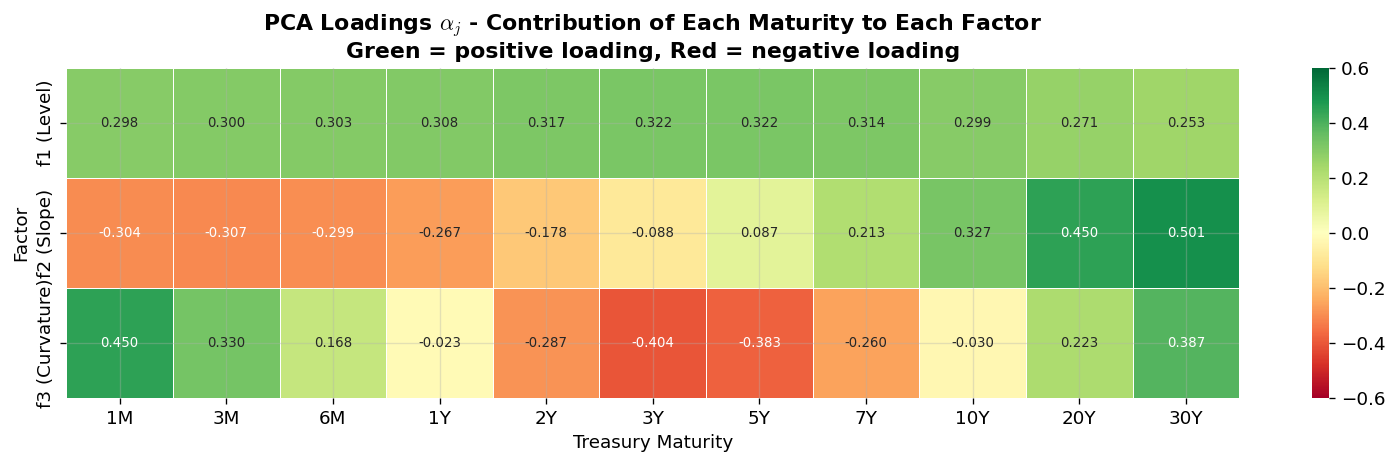

PCA loadings table:


,1M,3M,6M,1Y,2Y,3Y,5Y,7Y,10Y,20Y,30Y
f1 (Level),0.2983,0.3005,0.3034,0.3085,0.3174,0.3220,0.3223,0.3141,0.2992,0.2705,0.2529
f2 (Slope),-0.3043,-0.3071,-0.2987,-0.2674,-0.1778,-0.0885,0.0873,0.2125,0.3270,0.4496,0.5010
f3 (Curvature),0.4496,0.3301,0.1677,-0.0229,-0.2867,-0.4039,-0.3834,-0.2600,-0.0304,0.2234,0.3866


In [101]:
# Create the loadings DataFrame.
df_loadings = pd.DataFrame(
    pca3.components_,
    index=FACTOR_LABELS,
    columns=IR_LABELS
)

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    df_loadings,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn',
    center=0,
    vmin=-0.6,
    vmax=0.6,
    linewidths=0.4,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title(
    'PCA Loadings $\\alpha_j$ - Contribution of Each Maturity to Each Factor\n'
    'Green = positive loading, Red = negative loading',
    fontweight='bold'
)
ax.set_xlabel('Treasury Maturity')
ax.set_ylabel('Factor')
plt.tight_layout()
plt.show()

print('PCA loadings table:')
display(df_loadings.round(4))

#### Discussion on PCA loadings table and interpretation of factors.

&nbsp;&nbsp;&nbsp;&nbsp;As expected from class discussions, we have found that 3 factors is more than sufficient to explain the variance.

&nbsp;&nbsp;&nbsp;&nbsp;**f1 Level, explains 84.84% of variance**: All 11 loadings $\alpha_{1j}$ are positive and range from 0.25 to 0.32. When f1 rises, all rates move up proportionally, as shown by the correlation between f1 and the cross maturity mean rate $r = 0.998$.

&nbsp;&nbsp;&nbsp;&nbsp;**f2 Slope explains 13.83% of variance**: Loadings $\alpha_{2j}$ are negative at the for shorter timeframes and increase over longer timeframes. High f2 corresponds to a steep yield curve, shown by the correlation between f2 and the 10Y-3M term spread $r = 0.870$.

&nbsp;&nbsp;&nbsp;&nbsp;**f3 Curvature, explains 1.10% of variance**: Loadings $\alpha_{3j}$ are positive at the very short end, deeply negative in the intermediate range, and positive again at the very long end. This demonstrates situations where the very short and very long ends of the curve move in the opposite direction relative to intermediate maturities.

# Question 1 - Plots of Interest Rates, Factors, and S&P 500 Returns.

In [102]:
ir_colors = plt.cm.plasma(np.linspace(0.05, 0.92, len(IR_COLS)))

def annotate_events(ax):
    """Add vertical dashed lines and text labels for key macro events."""
    y_top = ax.get_ylim()[1]
    for date_str, label in EVENTS:
        ts = pd.Timestamp(date_str)
        ax.axvline(ts, color='black', lw=0.8, ls='--', alpha=0.45)
        ax.text(ts, y_top * 0.96, label,
                fontsize=7.5, color='black', ha='right', va='top', rotation=90)

## Figure 1 - All interest rates.

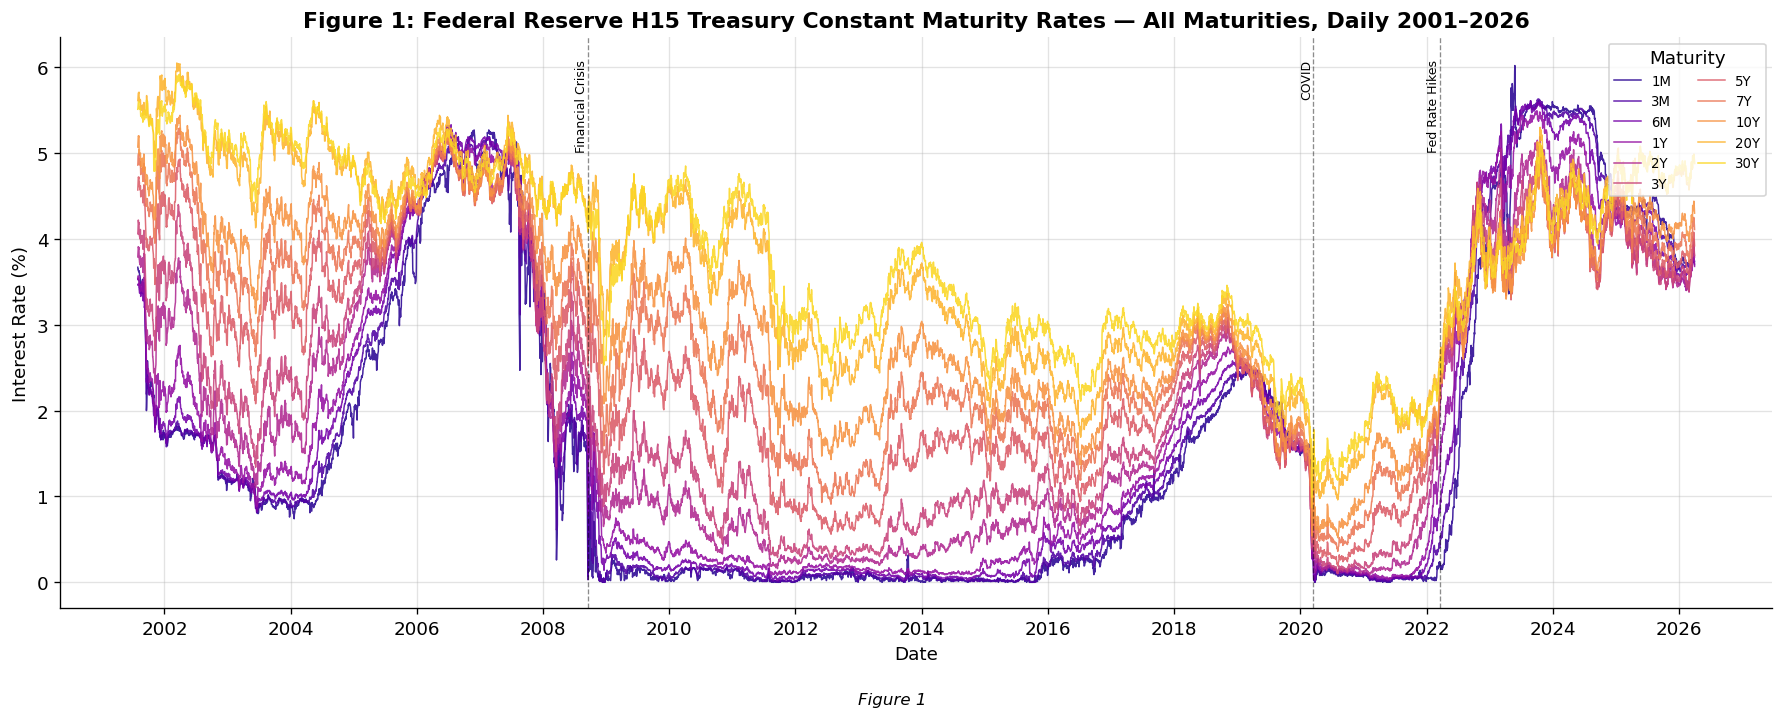

In [103]:
fig, ax = plt.subplots(figsize=(15, 6))

for col, label, color in zip(IR_COLS, IR_LABELS, ir_colors):
    ax.plot(df.index, df[col], lw=0.9, label=label, color=color, alpha=0.88)

ax.set_title(
    'Figure 1: Federal Reserve H15 Treasury Constant Maturity Rates — All Maturities, Daily 2001–2026',
    fontweight='bold'
)
ax.set_ylabel('Interest Rate (%)')
ax.set_xlabel('Date')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.legend(fontsize=8, ncol=2, loc='upper right', title='Maturity')
annotate_events(ax)

fig.text(0.5, 0.01, 'Figure 1', ha='center', fontsize=10, style='italic')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

#### Figure 1 Discussion — All Interest Rates.

&nbsp;&nbsp;&nbsp;&nbsp;From the graph, all maturities clearly move together and in the same direction, leading to concerns of multicollinearity. Using a factor model addresses this by extracting a small number of uncorrelated latent factors that summarize the common variation across all maturities. As shown in Table 1, just three factors explain 99.77% of the total covariation, reducing 11 highly correlated series to 3 orthogonal ones suitable for regression analysis.

## Figure 2 - All interest rates and the 3 factors.

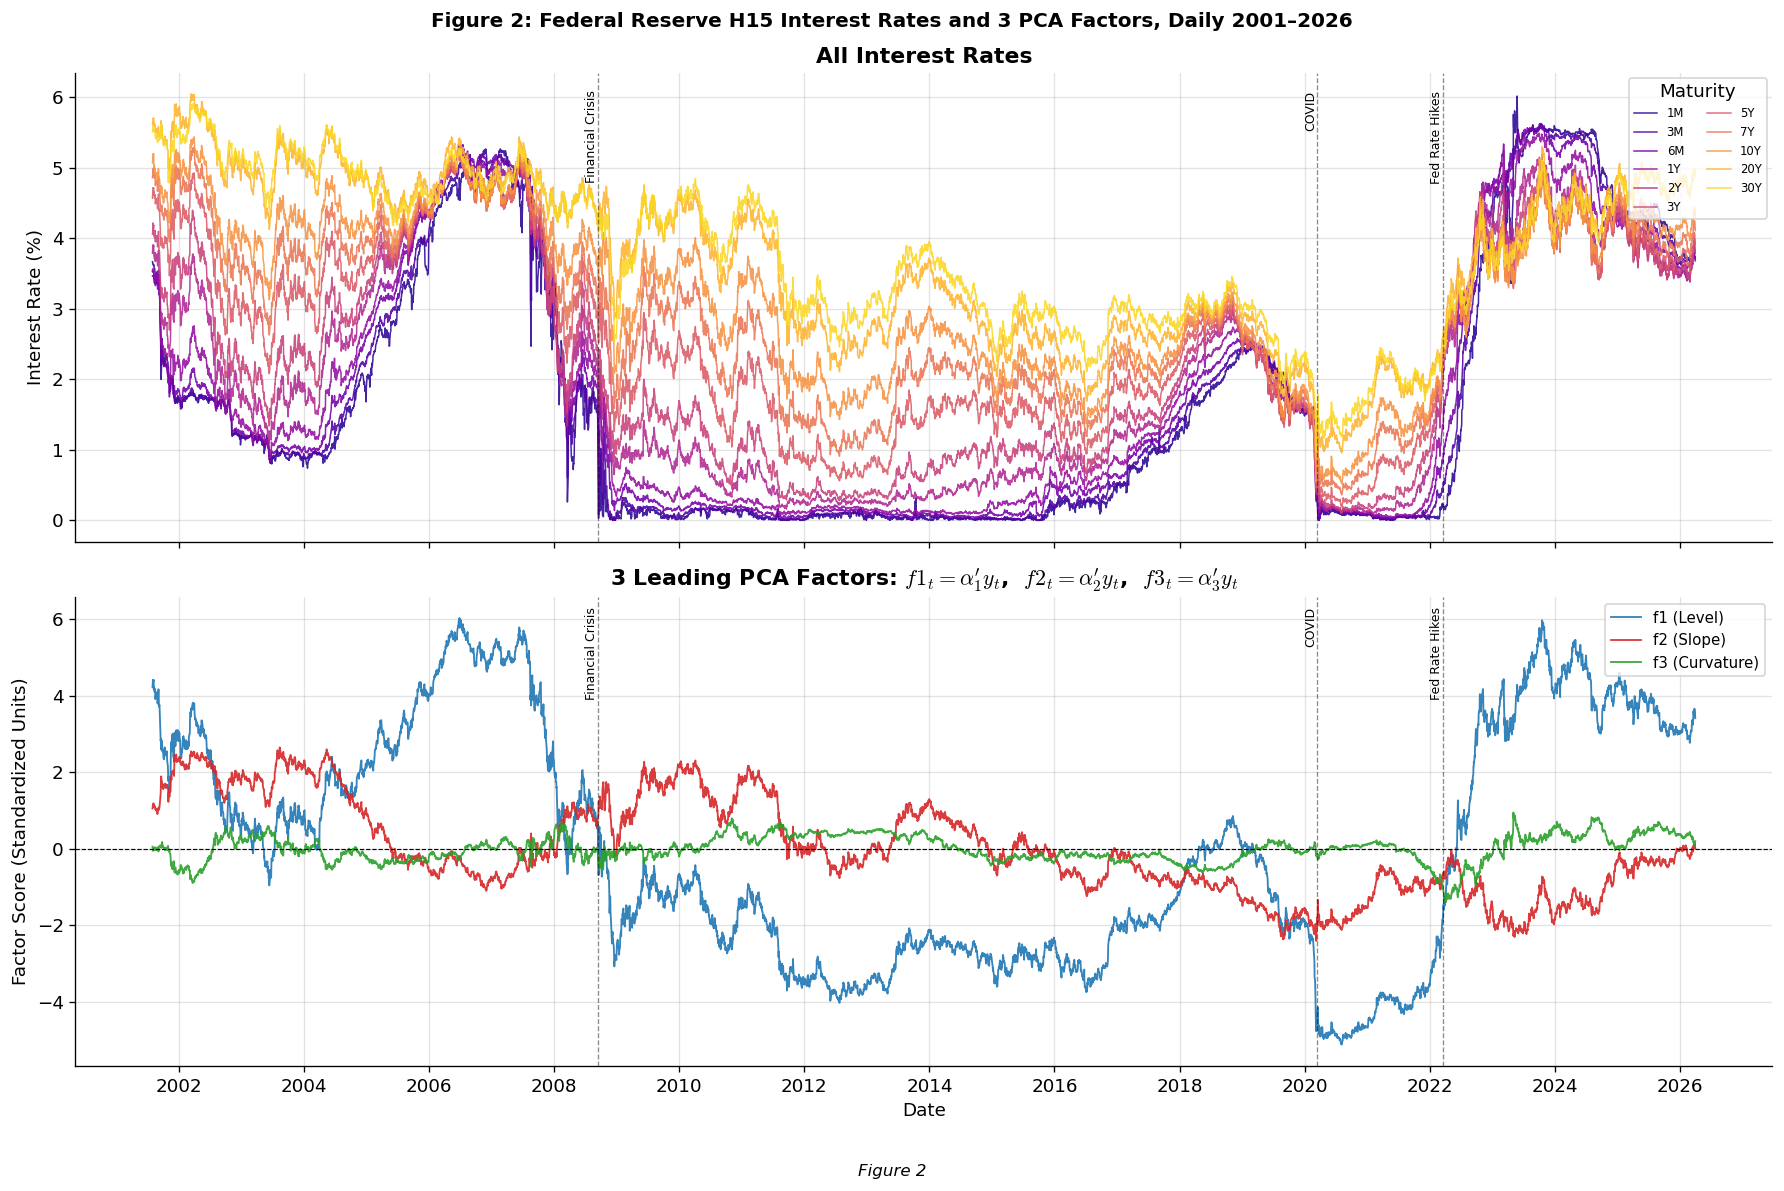

In [104]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

for col, label, color in zip(IR_COLS, IR_LABELS, ir_colors):
    axes[0].plot(df.index, df[col], lw=0.9, label=label, color=color, alpha=0.88)
axes[0].set_title('All Interest Rates', fontweight='bold')
axes[0].set_ylabel('Interest Rate (%)')
axes[0].legend(fontsize=7, ncol=2, loc='upper right', title='Maturity')

for col, label, color in zip(FACTOR_COLS, FACTOR_LABELS, FACTOR_COLORS):
    axes[1].plot(df.index, df[col], lw=1.1, label=label, color=color, alpha=0.9)
axes[1].axhline(0, color='black', lw=0.7, ls='--')
axes[1].set_title(
    r'3 Leading PCA Factors: $f1_t = \alpha_1^\prime y_t$,  $f2_t = \alpha_2^\prime y_t$,  $f3_t = \alpha_3^\prime y_t$',
    fontweight='bold'
)
axes[1].set_ylabel('Factor Score (Standardized Units)')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[1].xaxis.set_major_locator(mdates.YearLocator(2))
axes[1].legend(fontsize=9, loc='upper right')

for ax in axes:
    annotate_events(ax)

fig.suptitle(
    'Figure 2: Federal Reserve H15 Interest Rates and 3 PCA Factors, Daily 2001–2026',
    fontsize=12, fontweight='bold'
)
fig.text(0.5, 0.01, 'Figure 2', ha='center', fontsize=10, style='italic')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

#### Figure 2 Discussion — Interest Rates and Factors.

&nbsp;&nbsp;&nbsp;&nbsp;Figure 2 connects the 11 observed interest rate series to the three latent factors $f1_t = \alpha'_1 y_t$, $f2_t = \alpha'_2 y_t$, $f3_t = \alpha'_3 y_t$.

&nbsp;&nbsp;&nbsp;&nbsp;**f1 Level, blue**: Closely tracks the overall height of the yield curve. It peaks around 2006–2007, collapses to its minimum during the near-zero rate period of 2012–2015, drops sharply during COVID in 2020, then surges from 2022 onward. The correlation between f1 and the cross maturity mean rate is $r = 0.998$.

&nbsp;&nbsp;&nbsp;&nbsp;**f2 Slope, red**: Most positive during 2010–2013 when the Fed held short rates near zero while long rates remained elevated. Turns notably negative around 2006–2007 before the Financial Crisis, and again in 2022–2023 as the Fed raised short rates faster than long rates adjusted.

&nbsp;&nbsp;&nbsp;&nbsp;**f3 Curvature, green**: The smallest and flattest of the three factors, as we expect from the loading table.

## Figure 3 - All interest rates, 3 factors, and S&P 500 returns.

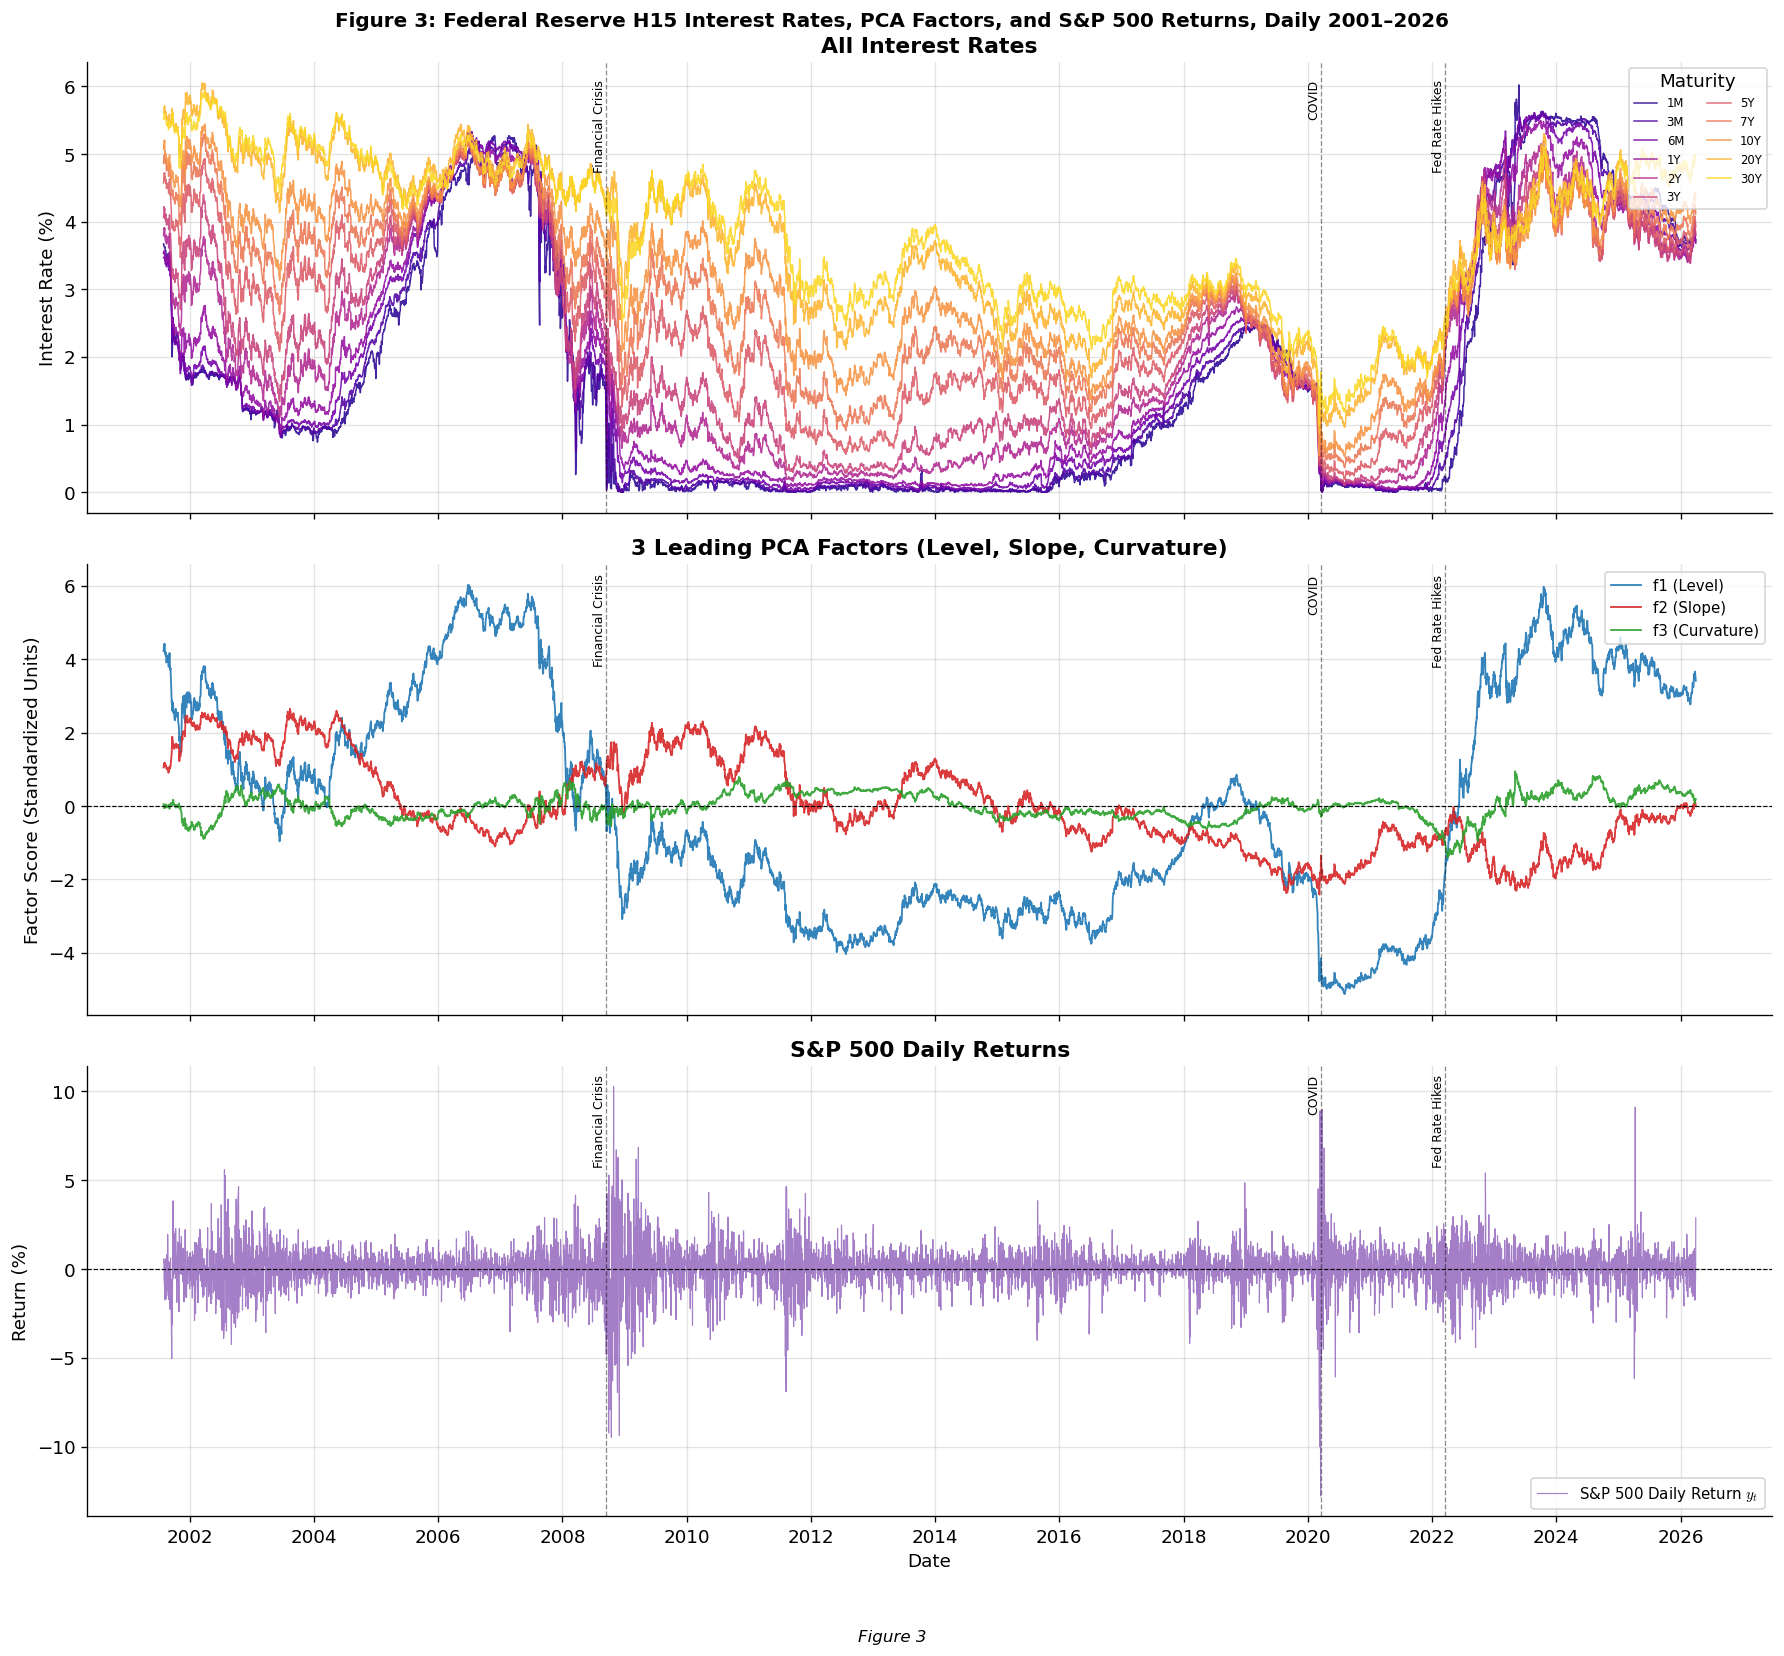

In [105]:
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)

for col, label, color in zip(IR_COLS, IR_LABELS, ir_colors):
    axes[0].plot(df.index, df[col], lw=0.9, label=label, color=color, alpha=0.88)
axes[0].set_title('All Interest Rates', fontweight='bold')
axes[0].set_ylabel('Interest Rate (%)')
axes[0].legend(fontsize=7, ncol=2, loc='upper right', title='Maturity')

for col, label, color in zip(FACTOR_COLS, FACTOR_LABELS, FACTOR_COLORS):
    axes[1].plot(df.index, df[col], lw=1.1, label=label, color=color, alpha=0.9)
axes[1].axhline(0, color='black', lw=0.7, ls='--')
axes[1].set_title('3 Leading PCA Factors (Level, Slope, Curvature)', fontweight='bold')
axes[1].set_ylabel('Factor Score (Standardized Units)')
axes[1].legend(fontsize=9, loc='upper right')

axes[2].plot(df.index, df['y'] * 100, lw=0.7, color='#9467bd', alpha=0.85,
             label='S&P 500 Daily Return $y_t$')
axes[2].axhline(0, color='black', lw=0.7, ls='--')
axes[2].set_title('S&P 500 Daily Returns', fontweight='bold')
axes[2].set_ylabel('Return (%)')
axes[2].set_xlabel('Date')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
axes[2].xaxis.set_major_locator(mdates.YearLocator(2))
axes[2].legend(fontsize=9, loc='lower right')

for ax in axes:
    annotate_events(ax)

fig.suptitle(
    'Figure 3: Federal Reserve H15 Interest Rates, PCA Factors, and S&P 500 Returns, Daily 2001–2026',
    fontsize=12, fontweight='bold'
)
fig.text(0.5, 0.01, 'Figure 3', ha='center', fontsize=10, style='italic')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

#### Figure 3 Discussion - Interest Rates, Factors, and S&P 500 Returns.

&nbsp;&nbsp;&nbsp;&nbsp;Adding the S&P 500 daily return series demonstrates a fundamental difference in movement between the interest rate data and S&P 500 returns, namely non-stationary versus stationary. The interest rate factors are clearly non-stationary, as f1 spends over a decade near its historical minimum before a sharp level shift in 2022. The S&P 500 returns appear to be stationary, fluctuating around a small positive mean.


# Question 2 - Regression Models.

#### Regression Models

Five OLS models are estimated with $y_t$ as the dependent variable, where all regressors are lagged one period to avoid any look ahead bias. We have:

$$\text{Model 1:} \quad y_t = a + \varepsilon_t$$

$$\text{Model 2:} \quad y_t = a + e\, y_{t-1} + \varepsilon_t$$

$$\text{Model 3:} \quad y_t = a + b\, f1_{t-1} + \varepsilon_t$$

$$\text{Model 4:} \quad y_t = a + b\, f1_{t-1} + c\, f2_{t-1} + d\, f3_{t-1} + \varepsilon_t$$

$$\text{Model 5:} \quad y_t = a + b\, f1_{t-1} + c\, f2_{t-1} + d\, f3_{t-1} + e\, y_{t-1} + \varepsilon_t$$

where $a, b, c, d, e$ are constants and $\varepsilon_t$ is the stochastic disturbance term.

#### OLS and R² (Lecture 5, slides 12–14).

The OLS estimator minimizes the sum of squared residuals:

$$\hat{\beta} = (X'X)^{-1} X'y$$

The coefficient of determination is:

$$R^2 = 1 - \frac{\sum_t \hat{\varepsilon}_t^2}{\sum_t (y_t - \bar{y})^2}$$

and the adjusted $R^2$ penalizes for additional regressors:

$$\bar{R}^2 = 1 - \frac{(1-R^2)(T-1)}{T-k}$$

where $T$ is the number of observations and $k$ is the number of estimated parameters.

#### HAC standard errors (Lecture 6).

Daily return data may exhibit serial correlation and heteroskedasticity, which would invalidate standard OLS standard errors. Following the methods in Lecture 6, all models are estimated using Newey-West HAC standard errors with `maxlags = 5`, approximately one trading week. The HAC variance-covariance matrix is given by:

$$\hat{V}_{\text{HAC}} = (X'X)^{-1} \hat{S} (X'X)^{-1}$$

where the long-run covariance matrix $\hat{S}$ is estimated as:

$$\hat{S} = \frac{1}{T}\sum_{t=1}^{T} \hat{\varepsilon}_t^2 x_t x_t' + \frac{1}{T}\sum_{\ell=1}^{L} w_\ell \sum_{t=\ell+1}^{T} \hat{\varepsilon}_t \hat{\varepsilon}_{t-\ell} \left(x_t x_{t-\ell}' + x_{t-\ell} x_t'\right)$$

with Bartlett weights $w_\ell = 1 - \ell/(L+1)$ and $L = 5$.

The t-statistic for each coefficient is:

$$t_j = \frac{\hat{\beta}_j}{\widehat{\text{se}}(\hat{\beta}_j)}$$

which is asymptotically $N(0,1)$ under the null $H_0: \beta_j = 0$. The two-sided 5% critical value is $|t| \approx 1.96$.

In [106]:
# Create all lagged regressors in a single vectorized assign call.
df = df.assign(
    y_lag1  = df['y'].shift(1),
    f1_lag1 = df['f1'].shift(1),
    f2_lag1 = df['f2'].shift(1),
    f3_lag1 = df['f3'].shift(1),
)

df_reg = df.dropna(subset=['y_lag1', 'f1_lag1', 'f2_lag1', 'f3_lag1']).copy()

assert not df_reg[['y', 'y_lag1', 'f1_lag1', 'f2_lag1', 'f3_lag1']].isnull().any().any(), \
    'Unexpected NaNs in regression sample.'
assert df_reg.index[0] > df.index[0], \
    'Regression sample must start after the first row as lag-1 produces one nan value.'

print(f'Regression sample: {df_reg.index[0].strftime("%Y-%m-%d")} to {df_reg.index[-1].strftime("%Y-%m-%d")}')
print(f'N = {len(df_reg):,} observations')

Regression sample: 2001-08-01 to 2026-03-31
N = 6,155 observations


In [107]:
# Patsy model syntax.
MODEL_SPECS = {
    'Model 1: Constant Only': 'y ~ 1',
    'Model 2: AR(1)': 'y ~ y_lag1',
    'Model 3: f1 Only': 'y ~ f1_lag1',
    'Model 4: All 3 Factors': 'y ~ f1_lag1 + f2_lag1 + f3_lag1',
    'Model 5: All 3 Factors + AR(1)': 'y ~ f1_lag1 + f2_lag1 + f3_lag1 + y_lag1',
}

fitted_models = {
    name: smf.ols(formula, data=df_reg).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': HAC_MAXLAGS}
    )
    for name, formula in MODEL_SPECS.items()
}

print('All 5 models fitted.')

All 5 models fitted.


## Model summaries.
#### Note: statsmodels labels the test statistic as 'z' rather than 't' when using HAC standard errors, as the statistic is asymptotically N(0,1) rather than t-distributed.

In [108]:
for name, model in fitted_models.items():
    print(f'\n{"="*70}')
    print(f' {name}')
    print(f'{"="*70}')
    print(model.summary())


 Model 1: Constant Only
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                  0.000
Method:                 Least Squares   F-statistic:                       nan
Date:                Thu, 16 Apr 2026   Prob (F-statistic):                nan
Time:                        00:30:48   Log-Likelihood:                 18491.
No. Observations:                6155   AIC:                        -3.698e+04
Df Residuals:                    6154   BIC:                        -3.697e+04
Df Model:                           0                                         
Covariance Type:                  HAC                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0003      

## Model comparison table.

In [109]:
def fmt_coef(model, pname):
    if pname not in model.params:
        return '—'
    c, t, p = model.params[pname], model.tvalues[pname], model.pvalues[pname]
    stars = '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    return f'{c:.5f} (t={t:.2f}){stars}'

rows = [
    {
        'Model': name,
        'R²': round(model.rsquared, 6),
        'Adj. R²': round(model.rsquared_adj, 6),
        'AIC': round(model.aic, 2),
        'N': int(model.nobs),
        'Intercept': fmt_coef(model, 'Intercept'),
        'y_lag1': fmt_coef(model, 'y_lag1'),
        'f1_lag1': fmt_coef(model, 'f1_lag1'),
        'f2_lag1': fmt_coef(model, 'f2_lag1'),
        'f3_lag1': fmt_coef(model, 'f3_lag1'),
    }
    for name, model in fitted_models.items()
]

df_comparison = pd.DataFrame(rows).set_index('Model')

print('Coefficients: estimate (HAC t-stat) | * p<0.10  ** p<0.05  *** p<0.01')
display(
    df_comparison.style
    .format({'R²': '{:.6f}', 'Adj. R²': '{:.6f}', 'AIC': '{:,.2f}'})
    .highlight_max(subset=['R²', 'Adj. R²'], color='lightgreen')
    .highlight_min(subset=['AIC'],           color='lightgreen')
    .set_caption('Table 2: Model Comparison - Dependent Variable: y_t, S&P 500 Daily Return')
)
print('Green, best ie highest R²/Adj. R²  or  lowest AIC).')

Coefficients: estimate (HAC t-stat) | * p<0.10  ** p<0.05  *** p<0.01


,R²,Adj. R²,AIC,N,Intercept,y_lag1,f1_lag1,f2_lag1,f3_lag1
Model,,,,,,,,,
Model 1: Constant Only,0.000000,0.000000,"-36,980.32",6155,0.00025 (t=1.80)*,—,—,—,—
Model 2: AR(1),0.011600,0.011439,"-37,050.13",6155,0.00028 (t=1.83)*,-0.10775 (t=-3.41)***,—,—,—
Model 3: f1 Only,0.000280,0.000117,"-36,980.04",6155,0.00025 (t=1.80)*,—,-0.00007 (t=-1.58),—,—
Model 4: All 3 Factors,0.002307,0.001820,"-36,988.53",6155,0.00025 (t=1.81)*,—,-0.00007 (t=-1.59),-0.00023 (t=-1.90)*,0.00132 (t=3.11)***
Model 5: All 3 Factors + AR(1),0.014191,0.013550,"-37,060.29",6155,0.00028 (t=1.84)*,-0.10910 (t=-3.47)***,-0.00007 (t=-1.54),-0.00024 (t=-1.84)*,0.00141 (t=3.04)***


Green, best ie highest R²/Adj. R²  or  lowest AIC).


## R² comparison chart.

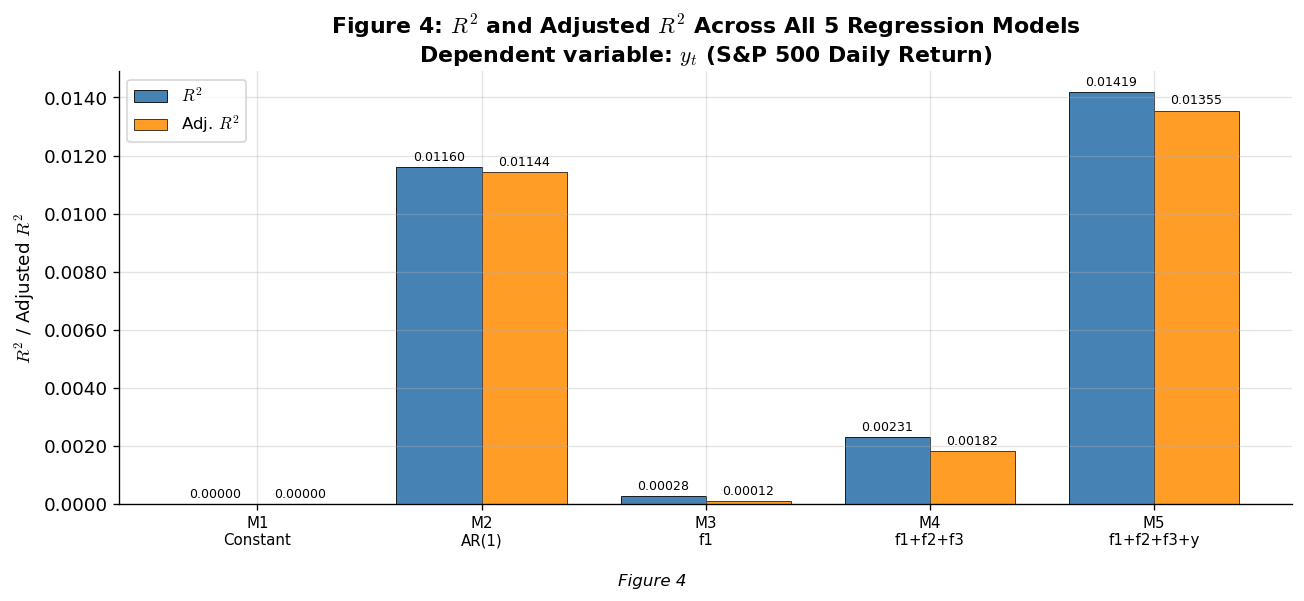

In [110]:
short_names = ['M1\nConstant', 'M2\nAR(1)', 'M3\nf1', 'M4\nf1+f2+f3', 'M5\nf1+f2+f3+y']
r2_vals = [m.rsquared for m in fitted_models.values()]
r2_adj_vals = [m.rsquared_adj for m in fitted_models.values()]

x = np.arange(len(short_names))
w = 0.38

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, r2_vals, w, label='$R^2$', color='steelblue',  edgecolor='black', lw=0.5)
b2 = ax.bar(x + w/2, r2_adj_vals, w, label='Adj. $R^2$', color='darkorange', edgecolor='black', lw=0.5, alpha=0.85)
ax.bar_label(b1, labels=[f'{v:.5f}' for v in r2_vals],     padding=2, fontsize=7.5)
ax.bar_label(b2, labels=[f'{v:.5f}' for v in r2_adj_vals], padding=2, fontsize=7.5)
ax.set_xticks(x)
ax.set_xticklabels(short_names, fontsize=9)
ax.set_ylabel('$R^2$ / Adjusted $R^2$')
ax.set_title(
    'Figure 4: $R^2$ and Adjusted $R^2$ Across All 5 Regression Models\n'
    'Dependent variable: $y_t$ (S&P 500 Daily Return)',
    fontweight='bold'
)
ax.legend(fontsize=10)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

fig.text(0.5, 0.01, 'Figure 4', ha='center', fontsize=10, style='italic')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

## Coefficient plot - estimates and 95% confidence intervals.

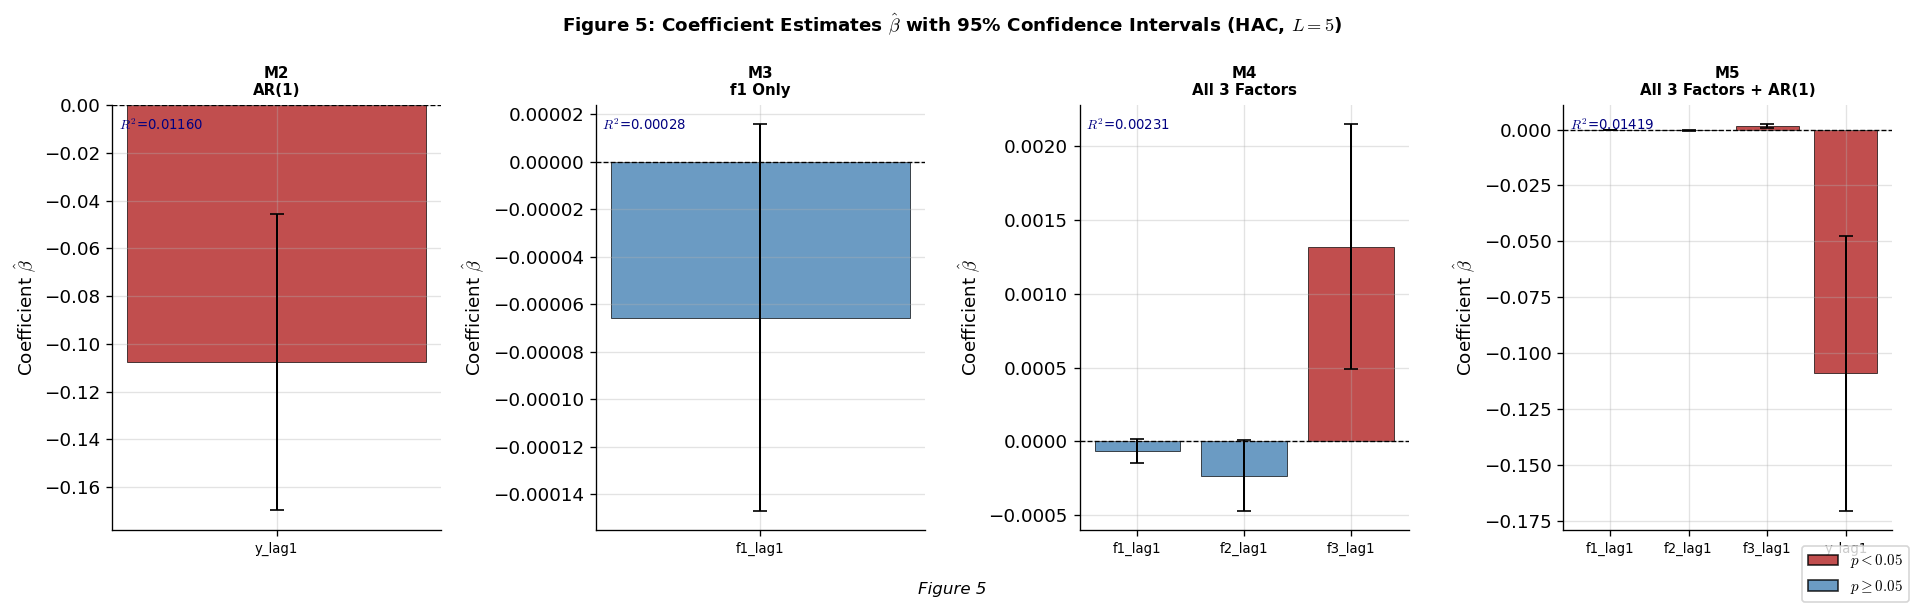

In [111]:
plot_models = {k: v for k, v in fitted_models.items() if k != 'Model 1: Constant Only'}

fig, axes = plt.subplots(1, len(plot_models), figsize=(16, 5))

for ax, (name, model) in zip(axes, plot_models.items()):
    params = model.params.drop('Intercept', errors='ignore')
    ci     = model.conf_int().drop('Intercept', errors='ignore')
    yerr   = np.array([params - ci[0], ci[1] - params])
    colors_bar = [
        'firebrick' if model.pvalues[p] < 0.05 else 'steelblue'
        for p in params.index
    ]
    ax.bar(params.index, params.values, color=colors_bar,
           alpha=0.8, edgecolor='black', linewidth=0.5)
    ax.errorbar(params.index, params.values, yerr=yerr,
                fmt='none', color='black', capsize=4, lw=1.2)
    ax.axhline(0, color='black', lw=0.8, ls='--')
    ax.set_title(name.replace('Model ', 'M').replace(': ', '\n'), fontsize=9, fontweight='bold')
    ax.set_ylabel('Coefficient $\\hat{\\beta}$')
    ax.tick_params(axis='x', labelsize=8)
    ax.text(0.02, 0.97, f'$R^2$={model.rsquared:.5f}',
            transform=ax.transAxes, fontsize=8, va='top', color='navy')

legend_elements = [
    Patch(facecolor='firebrick', edgecolor='black', alpha=0.8, label='$p < 0.05$'),
    Patch(facecolor='steelblue', edgecolor='black', alpha=0.8, label='$p \\geq 0.05$'),
]
fig.legend(handles=legend_elements, loc='lower right', fontsize=9)

fig.suptitle(
    'Figure 5: Coefficient Estimates $\\hat{\\beta}$ with 95% Confidence Intervals (HAC, $L=5$)',
    fontsize=11, fontweight='bold'
)
fig.text(0.5, 0.01, 'Figure 5', ha='center', fontsize=10, style='italic')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()

#### Discussion on regression results.

&nbsp;&nbsp;&nbsp;&nbsp;The regression results show that overall the models do not explain the data very well, with the best model (Model 5) having $R^2 = 0.0142$. Thus even in the best model here, 98.6% of daily return variation is not explained in the model.

&nbsp;&nbsp;&nbsp;&nbsp;**Model 1 (Constant only)**: $R^2 = 0$ by construction. The estimated daily mean return is $\hat{a} \approx 0.025\%$, only slightly significant at the 10% level ($p \approx 0.07$).

&nbsp;&nbsp;&nbsp;&nbsp;**Model 3 ($f1$ only)**: Adding the lagged level factor barely changes $R^2$ ($R^2 = 0.0003$). The coefficient on $f1_{t-1}$ is not statistically significant ($t \approx -1.58$, $p \approx 0.11$). The level of interest rates has no meaningful predictive power for next day equity returns.

&nbsp;&nbsp;&nbsp;&nbsp;**Model 4 (All 3 factors)**: $R^2 = 0.0023$. The **curvature factor $f3$ is statistically significant** ($t \approx 3.11$, $p \approx 0.002$). The **slope factor $f2$ is marginally significant** ($t \approx -1.90$, $p \approx 0.058$). A one-standard-deviation increase in $f3_{t-1}$ ($\sigma_{f3} = 0.347$) is associated with a change in next-day returns of $\hat{d} \cdot \sigma_{f3} = 0.001319 \times 0.347 \approx 0.046\%$.

&nbsp;&nbsp;&nbsp;&nbsp;**Model 2 (AR(1))**: This model achieves $R^2 = 0.0116$ using only the lagged return. The coefficient on $y_{t-1}$ is $\hat{e} \approx -0.108$, which is **highly significant** ($t \approx -3.41$, $p < 0.001$). This documents **negative first-order autocorrelation** in daily S&P 500 returns, ie if yesterday's return was $+1\%$, today's is expected to be about 0.11% lower. The economic interpretation of this is discussed in the following questions, Questions 3 and 4.

&nbsp;&nbsp;&nbsp;&nbsp;**Model 5 (All 3 factors + AR(1))**: $R^2 = 0.0142$. Both $y_{t-1}$ ($t \approx -3.47$, $p < 0.001$) and $f3_{t-1}$ ($t \approx 3.04$, $p = 0.002$) remain significant in the full model. The adjusted $\bar{R}^2 = 0.0136$ is nearly identical to $R^2$, indicating minimal overfitting from the additional regressors.


# Question 3 - Implications for the Efficient Market Hypothesis (EMH).

&nbsp;&nbsp;&nbsp;&nbsp;The EMH assumes that asset prices fully reflect all historical and public price information, meaning lagged returns should have no predictive power over future returns. While Model 2 finds a significant negative AR(1) coefficient and Models 4 and 5 find a significant $f3_{t-1}$ coefficient, all five models explain at most 1.4% of daily return variation. This is consistent with prior assignment findings where the naive mean was the best performing model for S&P 500 returns. Thus, the yield curve factors and lagged returns provide no meaningful forecasting improvement over simply using the historical mean, and we find that the EMH holds.

# Question 4 - Implications for Forecasting S&P 500 Returns.

&nbsp;&nbsp;&nbsp;&nbsp;As seen in Assignments 2 and 3, the naive mean is the best performing model for S&P 500 returns. This holds here as well, as all five models explain at most 1.4% of daily return variation, showing that the historical mean captures nearly as much of the variation as any of the more complex models.

&nbsp;&nbsp;&nbsp;&nbsp;While the yield curve factors f1, f2, and f3 are useful for analyzing the movement of interest rate, they provide no meaningful improvement for forecasting S&P 500 returns. The statistically significant $f3_{t-1}$ coefficient adds less than 0.3 percentage points of $R^2$ beyond the AR(1) model, and the AR(1) itself explains only 1.16% of variation. The naive mean remains the recommended forecasting model.